In [ ]:
import numpy as np
from matplotlib import pyplot as plt

from evaluation_package import filetools as ft
from evaluation_package import utils as ut
from evaluation_package import rabi
import evaluation_package.__version__ as version

In [2]:
# Specify the experiment type
experiment_type = "Rabi"

# Specify the subfolder list as a standard string path
subfolder = "01_Datafolder/01_Random_runs"

# Load the datafiles natively
yaml_config, data_list = ft.load_experiment_data(experiment_type, subfolders=subfolder, print=True, date_key="2025-12-12-12-07-52")
data = data_list[0]


The data of the following experiment is loaded: Rabi_2025-12-12-12-07-52.yaml


In [8]:
# Generate pulse duration arrays and contrast
mw_list_rabi = rabi.microwave_list(yaml_config)
y_Rabi = ut.contrast(data)

# Calculate parameters
pi_pulse_ns = rabi.pi_pulse_duration(yaml_config, data, savgol_filter=True) * 1e3
contrast_val = np.max(y_Rabi) - np.min(y_Rabi)
light_level_v = ut.average_light_level(yaml_config, data)

plt.figure(figsize=(8, 5))

# Create a clean multi-line label containing all stats
label_txt = (
    f"Rabi Oscillation\n"
    f"\u2022 Pi Pulse: {pi_pulse_ns:.2f} ns\n"
    f"\u2022 Contrast: {contrast_val:.4f}\n"
    f"\u2022 Light Lvl: {light_level_v:.4f} V\n"
    f"Package version: {version}"
)

# Plot the continuous line
plt.plot(mw_list_rabi, 1-y_Rabi, color="purple", label=label_txt)

plt.title(yaml_config["filename"])
plt.xlabel("MW Pulse duration (\u03bcs)")
plt.ylabel("Rabi Signal (a.u.)")
plt.legend(framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'version' is not defined

<Figure size 800x500 with 0 Axes>

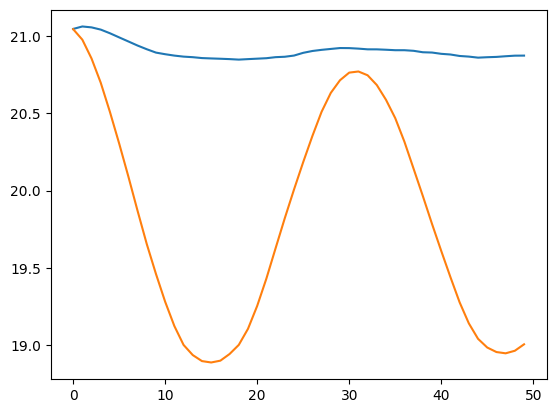

In [21]:
plt.plot(data[0].flatten())
plt.plot(data[1].flatten())